# **Graded Mini Project: Part A: City Library Management System**

**This library system achieves the following features using Python:**


*   Books and members are stored as plain dictionaries inside LibrarySimple.
*   Borrow/return events are recorded in a borrow log (list of event dictionaries).


**The notebook adds:**


*   Persistence: save/load state to JSON so data survives restarts.
*   Borrowing limit per member (configurable).

*   Overdue detection (simple loan duration rule).
*   A menu-driven Interface so a librarian can interactively use the system.










**In the beginning we set a few simple constants:**

In [ ]:
import datetime, json, os

STATE_FILE = '/content/ProjectFiles/PartA/library_state.json'   # filename for JSON persistence
LOAN_PERIOD_DAYS = 14               # how many days before a loan is overdue
MAX_BORROW_PER_MEMBER = 3           # max books a member may borrow at once

**Helper Mothods: this methods handle the printing of user understandable responses to the interactions done with the librabry management system**

In [ ]:
# ---------- Pretty Print Helpers ----------

def format_book(b):
    status = "Available" if b["available"] else "Issued"
    return f"{b['book_id']} | {b['title']} by {b['author']} | Genre: {b['genre']} | {status}"

def format_member(m):
    return f"{m['member_id']} | {m['name']} | Borrowed books: {', '.join(m['borrowed_books']) if m['borrowed_books'] else 'None'}"

def format_event(e, books, members):
    b = books[e["book_id"]]
    m = members[e["member_id"]]
    return (
        f"Transaction {e['transaction_id']}\n"
        f" Member: {m['member_id']} - {m['name']}\n"
        f" Book: {b['book_id']} - {b['title']}\n"
        f" Borrowed on: {e['borrow_date']}\n"
        f" Returned on: {e['return_date']}"
    )

def format_summary(summary):
    text = []
    text.append("Library Summary")
    text.append("--------------------------")
    text.append(f"Total books: {summary['total_books']}")
    text.append(f"Available: {summary['available']}")
    text.append(f"Issued: {summary['issued']}")
    text.append(f"Total members: {summary['total_members']}")
    text.append(f"Members currently holding books: {summary['members_with_borrowed_books']}")
    text.append("Top genres:")
    for g, c in summary["top_genres"]:
        text.append(f" - {g} ({c})")
    return "\n".join(text)

# **Helper constructors: new_book and new_member**
These are tiny functions to create the dictionary representing a book or a member.


*   Each book has available (True/False).
*   Each member has borrowed_books: a list of book IDs they currently hold.



In [ ]:
# Helper constructors
def new_book(book_id, title, author, genre):
    return {
        'book_id': book_id,
        'title': title,
        'author': author,
        'genre': genre,
        'available': True
    }

def new_member(member_id, name, age, contact):
    return {
        'member_id': member_id,
        'name': name,
        'age': age,
        'contact': contact,
        'borrowed_books': []
    }

# **LibrarySimple class - the core system**
*   The class holds the state and the methods to operate on it.
*   books and members are dictionaries keyed by IDs for fast lookups.
*   borrow_log preserves history chronologically (append-only).

# **Persistence: save_state and load_state**
These let you persist the current library state to a JSON file and restore it later.


*   save_state converts in-memory objects into JSON-friendly values, especially dates.
*   load_state reads JSON and re-creates date objects for borrow events.

**Two small helpers handle date conversion:**

*   _serialize_event(e): convert date objects to ISO strings before JSON.
*   _deserialize_event(e): convert ISO strings back to datetime.date.

Why? JSON cannot store datetime.date objects directly, so we use ISO string (YYYY-MM-DD) which is human readable and standard.

# **ID generation: _next_tx**

*   Transaction IDs are generated like TX00001 for readability and traceability.

# **Book and member management methods**
**add_book(book_id, title, author, genre)**

*  Validates that book_id is provided and not already present.

*  Creates and stores a new book dict.

**update_book(book_id, fields)**

* Update fields (e.g., change title or genre). Simple dict.update().**

**add_member(member_id, name, age, contact)**

* Validates ID uniqueness and creates a member dict.

# **Borrowing & Returning with validations**
**borrow_book(member_id, book_id, borrow_date=None)**

**Steps it performs:**

1.   Default borrow date to today if not given.

2.   Ensure member_id and book_id exist (raises KeyError otherwise).

3.   Check member borrow count: if >= MAX_BORROW_PER_MEMBER -> raise ValueError.

4.   Check book availability (available flag): if not available -> raise ValueError.

5.   Set book['available'] = False and add book_id to member['borrowed_books'].

6.   Generate a transaction ID, create an event dict

7.   Append event to borrow_log and return it.



**return_book(member_id, book_id, return_date=None)**

**Steps it performs:**

1. Default return_date to today if not provided.

2. Validate member_id and book_id.

3. Check that book_id is in the member’s borrowed_books. If not -> raise error.

4. Mark the book available and remove the book ID from member’s borrowed_books.

5. Find the most recent borrow event with return_date is None for that member+book and set its return_date.

6. Return the updated event.

This keeps the borrow log correct (borrowed and returned events are matched).





# **Search & Reports methods**
**search_books(title=None, author=None)**
**Steps it performs:**

* Case-insensitive substring search on title and/or author.

* Returns list of matching book dicts.

* Useful for librarians and for showing search results in your UI or report.

**available_books_by_genre(genre)**

**Steps it performs:**

* Returns available books for a given genre (case-insensitive).

**members_with_borrowed_books()**

**Steps it performs:**

* Returns members who currently have borrowed books (non-empty borrowed_books list).

**most_popular_genres(top_n=3)**

**Steps it performs:**

* Counts genres across the borrow log (counts each borrow event).

* Returns top top_n genres sorted by count (e.g., [('Fantasy', 10), ('Sci-Fi', 6)]).

Why count borrow events? Popularity is usually measured by how often books in a genre are borrowed, not just how many copies exist.

**overdue_books()**

**Steps it performs:**

* Iterates borrow log and finds events where return_date is None and days_since_borrow > LOAN_PERIOD_DAYS.

* Returns a small list of dictionaries with transaction_id, member_id, book_id, and days_overdue.

This helps the librarian identify who to follow up with about late returns.

**library_summary()**

**Steps it performs:**

* Returns a small dictionary with:

* total books

* currently available books

* issued count

* number of members

* number of members with borrowed books

* top genres (via most_popular_genres)

In [ ]:
class LibrarySimple:
    def __init__(self):
        self.books = {}
        self.members = {}
        self.borrow_log = []
        self._tx_counter = 0

    # ---------- Persistence ----------
    def save_state(self, path=STATE_FILE):
        state = {
            "books": self.books,
            "members": self.members,
            "borrow_log": [self._serialize_event(e) for e in self.borrow_log],
            "_tx_counter": self._tx_counter
        }
        with open(path, "w", encoding="utf-8") as f:
            json.dump(state, f, indent=2, default=str)

    def load_state(self, path=STATE_FILE):
        if not os.path.exists(path):
            return False
        try:
            with open(path, "r", encoding="utf-8") as f:
                content = f.read().strip()
                if not content:
                    print("Warning: empty state file. Fresh start.")
                    return False
                state = json.loads(content)
        except json.JSONDecodeError:
            print("Warning: corrupted state file. Fresh start.")
            return False

        self.books = state.get("books", {})
        self.members = state.get("members", {})
        self.borrow_log = [self._deserialize_event(e) for e in state.get("borrow_log", [])]
        self._tx_counter = state.get("_tx_counter", 0)
        return True

    def _serialize_event(self, e):
        ev = e.copy()
        if isinstance(ev["borrow_date"], datetime.date):
            ev["borrow_date"] = ev["borrow_date"].isoformat()
        if ev["return_date"] and isinstance(ev["return_date"], datetime.date):
            ev["return_date"] = ev["return_date"].isoformat()
        return ev

    def _deserialize_event(self, e):
        ev = e.copy()
        ev["borrow_date"] = datetime.date.fromisoformat(ev["borrow_date"])
        if ev["return_date"]:
            ev["return_date"] = datetime.date.fromisoformat(ev["return_date"])
        return ev

    # ---------- Transaction ID ----------
    def _next_tx(self):
        self._tx_counter += 1
        return "TX" + str(self._tx_counter).zfill(5)

    # ---------- Book & Member Management ----------
    def add_book(self, book_id, title, author, genre):

        if not int(str(book_id)): # Attempt to convert to integer
            raise ValueError("Book ID must be a valid integer.")

        if book_id in self.books:
            raise ValueError("Book ID already exists.")
        self.books[book_id] = new_book(book_id, title, author, genre)

    def add_member(self, member_id, name, age, contact):
        if member_id in self.members:
            raise ValueError("Member ID already exists.")
        self.members[member_id] = new_member(member_id, name, age, contact)

    # ---------- Borrow ----------
    def borrow_book(self, member_id, book_id, borrow_date=None):
        if borrow_date is None:
            borrow_date = datetime.date.today()

        if member_id not in self.members:
            raise ValueError("Member not found.")
        if book_id not in self.books:
            raise ValueError("Book not found.")

        member = self.members[member_id]
        book = self.books[book_id]

        if len(member["borrowed_books"]) >= MAX_BORROW_PER_MEMBER:
            raise ValueError("Member reached borrow limit.")

        if not book["available"]:
            raise ValueError("Book is already issued.")

        # perform borrow
        book["available"] = False
        member["borrowed_books"].append(book_id)

        tx = self._next_tx()
        e = {
            "transaction_id": tx,
            "member_id": member_id,
            "book_id": book_id,
            "borrow_date": borrow_date,
            "return_date": None
        }
        self.borrow_log.append(e)
        return format_event(e, self.books, self.members)

    # ---------- Return ----------
    def return_book(self, member_id, book_id, return_date=None):
        if return_date is None:
            return_date = datetime.date.today()

        if member_id not in self.members:
            raise ValueError("Member not found.")
        if book_id not in self.books:
            raise ValueError("Book not found.")

        member = self.members[member_id]
        book = self.books[book_id]

        if book_id not in member["borrowed_books"]:
            raise ValueError("This member did not borrow that book.")

        book["available"] = True
        member["borrowed_books"].remove(book_id)

        for e in reversed(self.borrow_log):
            if e["member_id"] == member_id and e["book_id"] == book_id and e["return_date"] is None:
                e["return_date"] = return_date
                return format_event(e, self.books, self.members)

        raise RuntimeError("Borrow record not found.")

    # ---------- Search ----------
    def search_books(self, title=None, author=None):
        results = []
        title = title.lower() if title else None
        author = author.lower() if author else None

        for b in self.books.values():
            if title and title not in b["title"].lower():
                continue
            if author and author not in b["author"].lower():
                continue
            results.append(format_book(b))

        return results

    # ---------- Reports ----------
    def available_books_by_genre(self, genre):
        genre = genre.lower()
        return [format_book(b) for b in self.books.values()
                if b["genre"].lower() == genre and b["available"]]

    def members_with_borrowed_books(self):
        return [format_member(m) for m in self.members.values()
                if m["borrowed_books"]]

    def overdue_books(self):
        today = datetime.date.today()
        result = []
        for e in self.borrow_log:
            if e["return_date"] is None:
                days = (today - e["borrow_date"]).days
                if days > LOAN_PERIOD_DAYS:
                    result.append(
                        f"Transaction {e['transaction_id']} | "
                        f"Book {e['book_id']} | Member {e['member_id']} | "
                        f"Overdue by {days - LOAN_PERIOD_DAYS} days"
                    )
        return result

    def library_summary(self):
        summary = {
            "total_books": len(self.books),
            "available": sum(1 for b in self.books.values() if b["available"]),
            "issued": sum(1 for b in self.books.values() if not b["available"]),
            "total_members": len(self.members),
            "members_with_borrowed_books": sum(1 for m in self.members.values() if m["borrowed_books"]),
            "top_genres": self.most_popular_genres()
        }
        return format_summary(summary)

    def most_popular_genres(self, top_n=3):
        counts = {}
        for e in self.borrow_log:
            g = self.books[e["book_id"]]["genre"]
            counts[g] = counts.get(g, 0) + 1
        return sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

# **Initialize and optionally load previous state**


Run the cell below to create a library instance. If library_state.json exists in the folder, the state will be loaded.

**NOTE: RUN THIS AFTER EVERY SAVE STATE OPERATION PERFORMED, TO GET LATEST STATE DATA**

In [ ]:
# Create library and load state if available
lib = LibrarySimple()
loaded = lib.load_state()
if loaded:
    print('Previous library state loaded from', STATE_FILE)
else:
    # add some sample data
    lib.add_book('1', 'The Hobbit', 'J.R.R. Tolkien', 'Fantasy')
    lib.add_book('2', '1984', 'George Orwell', 'Dystopian')
    lib.add_book('3', 'A Brief History of Time', 'Stephen Hawking', 'Science')
    lib.add_book('4', 'To Kill a Mockingbird', 'Harper Lee', 'Classic')
    lib.add_book('5', 'The Great Gatsby', 'F. Scott Fitzgerald', 'Classic')
    lib.add_book('6', 'Pride and Prejudice', 'Jane Austen', 'Romance')

    lib.add_member('M001', 'Alice Gupta', 28, 'alice@gmail.com')
    lib.add_member('M002', 'Ravi Kumar', 35, 'ravi@gmail.com')

    print('Initialized sample library. Save state after operations to persist.')

Previous library state loaded from /content/ProjectFiles/library_state.json


# **Interactive CLI for menu-driven approch**

In [ ]:
def print_menu():
    print("\n--- City Library CLI Menu ---")
    print("1. Add book")
    print("2. Add member")
    print("3. Borrow book")
    print("4. Return book")
    print("5. Search books")
    print("6. List available books by genre")
    print("7. Members with borrowed books")
    print("8. Library summary")
    print("9. Show borrow log")
    print("10. Show overdue books")
    print("11. Save state")
    print("0. Exit")

def cli_loop(lib):
    while True:
        print_menu()
        choice = input("Enter your choice (0-11): ").strip()

        try:
            if choice == "1":
                bid = input("Book ID: ")
                title = input("Title: ")
                author = input("Author: ")
                genre = input("Genre: ")
                lib.add_book(bid, title, author, genre)
                print("Book added.")

            elif choice == "2":
                mid = input("Member ID: ")
                name = input("Name: ")
                age = int(input("Age: "))
                contact = input("Contact: ")
                lib.add_member(mid, name, age, contact)
                print("Member added.")

            elif choice == "3":
                mid = input("Member ID: ")
                bid = input("Book ID: ")
                print(lib.borrow_book(mid, bid))

            elif choice == "4":
                mid = input("Member ID: ")
                bid = input("Book ID: ")
                print(lib.return_book(mid, bid))

            elif choice == "5":
                t = input("Search title: ").strip()
                a = input("Search author: ").strip()
                results = lib.search_books(t or None, a or None)
                if results:
                    for r in results: print(r)
                else:
                    print("No books found.")

            elif choice == "6":
                g = input("Genre: ")
                results = lib.available_books_by_genre(g)
                if results:
                    for r in results: print(r)
                else:
                    print("No books available in this genre.")

            elif choice == "7":
                members = lib.members_with_borrowed_books()
                if not members:
                    print("No members currently holding books.")
                else:
                    for m in members: print(m)

            elif choice == "8":
                print(lib.library_summary())

            elif choice == "9":
                for e in lib.borrow_log:
                    print(format_event(e, lib.books, lib.members))

            elif choice == "10":
                overdue = lib.overdue_books()
                if overdue:
                    for o in overdue: print(o)
                else:
                    print("No overdue books.")

            elif choice == "11":
                lib.save_state()
                print("Library state saved.")

            elif choice == "0":
                print("Goodbye!")
                break

            else:
                print("Invalid choice. Enter 0-11.")

        except Exception as err:
            print("Error:", err)

print('CLI ready. Run cli_loop(lib) to start.')


CLI ready. Run cli_loop(lib) to start.


In [ ]:
cli_loop(lib)

# **call cli_loop(lib) to start the interactive menu**

# **THE COMPLETE EXECUTION LOG OF TEST SCENARIO WITH EXPLAINATION**



# This is formatted as code



--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR ADDING NEW BOOK**
```
Enter your choice (0-11): 1
Book ID: 7
Title: The Catcher in the Rye
Author: J.D. Salinger
Genre: Classic
Book added.
```

--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR ADDING NEW BOOK**
```
Enter your choice (0-11): 1
Book ID: 8
Title: The Fault in Our Stars
Author: John Green
Genre: Romance
Book added.
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR ADDING NEW MEMBER**
```
Enter your choice (0-11): 2
Member ID: M003
Name: Bob Dylan
Age: 34
Contact: bob@gmail.com
Member added.
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR ADDING NEW MEMBER**
```
Enter your choice (0-11): 2
Member ID: M004
Name: Sara Williams
Age: 22
Contact: sara.w@gmail.com
Member added.
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR GETTING LIST OF BORROWED BOOKS**
```
Enter your choice (0-11): 3
Member ID: M003
Book ID: 2
Transaction TX00001
 Member: M003 - Bob Dylan
 Book: 2 - 1984
 Borrowed on: 2025-11-17
 Returned on: None
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR SEARCHING BOOK BY TITLE**
```
Enter your choice (0-11): 5
Search title: The Great Gatsby
Search author:
5 | The Great Gatsby by F. Scott Fitzgerald | Genre: Classic | Available
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR SEARCHING BOOK BY AUTHOR**
```
Enter your choice (0-11): 5
Search title:
Search author: George Orwell
2 | 1984 by George Orwell | Genre: Dystopian | Issued
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR LISTING BOOKS BY GENERE**
```
Enter your choice (0-11): 6
Genre: romance
6 | Pride and Prejudice by Jane Austen | Genre: Romance | Available
8 | The Fault in Our Stars by John Green | Genre: Romance | Available
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR LISTING BOOKS BY GENERE**
```
Enter your choice (0-11): 6
Genre: classic
4 | To Kill a Mockingbird by Harper Lee | Genre: Classic | Available
5 | The Great Gatsby by F. Scott Fitzgerald | Genre: Classic | Available
7 | The Catcher in the Rye by J.D. Salinger | Genre: Classic | Available
```

--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR LISTING OF MEMBERS WITH BORROWED BOOKS**
```
Enter your choice (0-11): 7
M003 | Bob Dylan | Borrowed books: 2
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR LISTING LIBRARY SUMMARY**
```
Enter your choice (0-11): 8
Library Summary
--------------------------
Total books: 8
Available: 7
Issued: 1
Total members: 4
Members currently holding books: 1
Top genres:
 - Dystopian (1)
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR DISPLAYING BORROWER LOGS**
```
Enter your choice (0-11): 9
Transaction TX00001
 Member: M003 - Bob Dylan
 Book: 2 - 1984
 Borrowed on: 2025-11-17
 Returned on: None
```

--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR LISTING OVERDUE BOOKS**
```
Enter your choice (0-11): 10
No overdue books.
```
--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR SAVING CURRENT STATE TO JSON**
```
Enter your choice (0-11): 11
Library state saved.
```

--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR EXITING THE CLI**
```
Enter your choice (0-11): 0
Goodbye!
```

--- City Library CLI Menu ---
1. Add book
2. Add member
3. Borrow book
4. Return book
5. Search books
6. List available books by genre
7. Members with borrowed books
8. Library summary
9. Show borrow log
10. Show overdue books
11. Save state
0. Exit

**TEST FOR RETURNING THE BOOK**
```
Enter your choice (0-11): 4
Member ID: M003
Book ID: 2
Transaction TX00001
 Member: M003 - Bob Dylan
 Book: 2 - 1984
 Borrowed on: 2025-11-17
 Returned on: 2025-11-17
```

# **THE library_state.json file after state save of this execution**



```
{
  "books": {
    "1": {
      "book_id": "1",
      "title": "The Hobbit",
      "author": "J.R.R. Tolkien",
      "genre": "Fantasy",
      "available": true
    },
    "2": {
      "book_id": "2",
      "title": "1984",
      "author": "George Orwell",
      "genre": "Dystopian",
      "available": false
    },
    "3": {
      "book_id": "3",
      "title": "A Brief History of Time",
      "author": "Stephen Hawking",
      "genre": "Science",
      "available": true
    },
    "4": {
      "book_id": "4",
      "title": "To Kill a Mockingbird",
      "author": "Harper Lee",
      "genre": "Classic",
      "available": true
    },
    "5": {
      "book_id": "5",
      "title": "The Great Gatsby",
      "author": "F. Scott Fitzgerald",
      "genre": "Classic",
      "available": true
    },
    "6": {
      "book_id": "6",
      "title": "Pride and Prejudice",
      "author": "Jane Austen",
      "genre": "Romance",
      "available": true
    },
    "7": {
      "book_id": "7",
      "title": "The Catcher in the Rye",
      "author": "J.D. Salinger",
      "genre": "Classic",
      "available": true
    },
    "8": {
      "book_id": "8",
      "title": "The Fault in Our Stars",
      "author": "John Green",
      "genre": "Romance",
      "available": true
    }
  },
  "members": {
    "M001": {
      "member_id": "M001",
      "name": "Alice Gupta",
      "age": 28,
      "contact": "alice@gmail.com",
      "borrowed_books": []
    },
    "M002": {
      "member_id": "M002",
      "name": "Ravi Kumar",
      "age": 35,
      "contact": "ravi@gmail.com",
      "borrowed_books": []
    },
    "M003": {
      "member_id": "M003",
      "name": "Bob Dylan",
      "age": 34,
      "contact": "bob@gmail.com",
      "borrowed_books": [
        "2"
      ]
    },
    "M004": {
      "member_id": "M004",
      "name": "Sara Williams",
      "age": 22,
      "contact": "sara.w@gmail.com",
      "borrowed_books": []
    }
  },
  "borrow_log": [
    {
      "transaction_id": "TX00001",
      "member_id": "M003",
      "book_id": "2",
      "borrow_date": "2025-11-17",
      "return_date": null
    }
  ],
  "_tx_counter": 1
}
```



# **Graded Mini Project: Part B: Retail Transaction Insights**

**This Retail transaction presentation system the following features using Python:**

* Safe CSV loading + robust date parsing

* Cleaned dataset saved to Retail_Transactions_Cleaned.csv

* Feature engineering: Year, Month, MonthName, DayOfWeek, Season

* Charts: transactions by city, payment method distribution, monthly revenue trend, seasonal revenue (and heatmaps)

* Promotion & discount analysis, top products, customer behaviour (avg spend)

* CLI (partb_cli(df)) to run analyses interactively and save plots for the report

* Plots saved to partb_plots/ for easy inclusion in the final PDF

**Imports & Setup**

* os = utilities for files and folders (check if a file exists, create folders).

* pandas (pd) = the main data tool. It loads the CSV and gives you tables (DataFrames) to work with.

* matplotlib.pyplot (plt) & seaborn = plotting libraries to make charts.

* sns.set() gives nicer default plot styles.

* PLOTS_DIR is where the notebook will save PNG plot images. os.makedirs(..., exist_ok=True) creates that folder if it isn’t already there.

In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import ast
import re

sns.set()
PLOTS_DIR = '/content/ProjectFiles/PartB/partb_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

**Small helper functions**

* save_plot: saves the current Matplotlib plot to the partb_plots folder and prints the path.

* month_to_season: maps month numbers (1-12) to human-readable seasons. Used to create a Season column.

* safe_display: tries to uses display() function to display table, if it fails textual info will be displayed

In [41]:
def save_plot(filename):
    """Save current matplotlib figure into PLOTS_DIR and print path."""
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, bbox_inches='tight')
    print('Saved plot to', path)

def month_to_season(m):
    if m in [3,4,5]: return 'Spring'
    if m in [6,7,8]: return 'Summer'
    if m in [9,10,11]: return 'Autumn'
    return 'Winter'


def safe_display(df, n=5):
    """Show a small preview in both notebook and plain environments."""
    try:
        display(df.head(n))
    except Exception:
        print(df.head(n).to_string())


def extract_products(cell):
    """
    Given a cell which may be:
      - a Python-list-like string: "['A','B']"
      - a comma-separated string: "A, B, C"
      - already a list
    Return a cleaned list of product names (no quotes/brackets, trimmed).
    """
    if pd.isna(cell):
        return []
    # If it's already a list/tuple, normalize and return
    if isinstance(cell, (list, tuple)):
        return [str(x).strip() for x in cell if x is not None and str(x).strip()]
    s = str(cell).strip()
    # Try safe Python literal parsing (handles "['A', 'B']" and '["A", "B"]')
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple)):
            return [str(x).strip() for x in parsed if x is not None and str(x).strip()]
    except Exception:
        pass
    # Fallback: remove square brackets and quotes, then split by comma
    s_clean = re.sub(r'[\[\]\"]', '', s)      # remove [ ] and double quotes
    s_clean = s_clean.replace("'", "")        # remove single quotes
    parts = [p.strip() for p in s_clean.split(',') if p.strip()]
    return parts

**Load CSV and initial validation**

* Checks the CSV exists; if not, it raises a clear error.

* pd.read_csv loads the file into a DataFrame df.

* df.shape gives rows and columns.

* df.columns = [c.strip() ...] removes stray whitespace from column names (common cause of bugs).

In [42]:
DATA_FILE = '/content/ProjectFiles/PartB/Retail_Transactions_Dataset.csv'
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"{DATA_FILE} not found. Upload the CSV to the notebook folder and re-run.")

df = pd.read_csv(DATA_FILE)
print("Loaded rows, cols:", df.shape)
print("Columns:", df.columns.tolist())

# normalize column names (strip whitespace)
df.columns = [c.strip() for c in df.columns]


Loaded rows, cols: (1000000, 13)
Columns: ['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items', 'Total_Cost', 'Payment_Method', 'City', 'Store_Type', 'Discount_Applied', 'Customer_Category', 'Season', 'Promotion']


**Detect and parse the date column**
* The code looks for a column whose name contains "date" (or is commonly named). This is flexible to handle different CSV formats.

* pd.to_datetime(..., errors='coerce') converts strings to datetime; rows it cannot parse become NaT (missing).

* It counts unparseable dates and drops rows where the date couldn’t be interpreted to avoid downstream errors.

In [43]:
# find date column robustly
date_candidates = [c for c in df.columns if 'date' in c.lower() or c.lower() in ('date','transaction_date','order_date')]
if not date_candidates:
    raise ValueError("No date-like column found. Please rename your date column to contain 'date' or use 'Transaction_Date'.")
date_col = date_candidates[0]
print("Using date column:", date_col)

# parse dates (coerce bad strings to NaT)
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
bad_dates = df[date_col].isna().sum()
print("Unparseable dates (will be dropped):", bad_dates)
df = df.dropna(subset=[date_col]).copy()

Using date column: Date
Unparseable dates (will be dropped): 0


**Create date-related features**

* Adds columns that are very useful in time-based analysis: Year, Month, MonthName, DayOfWeek, and Season.

* These let you easily aggregate by month/season/day without repeatedly parsing dates.

In [44]:
# create date features
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['MonthName'] = df[date_col].dt.strftime('%b')
df['DayOfWeek'] = df[date_col].dt.day_name()
df['Season'] = df['Month'].apply(month_to_season)

**Numeric coercion for common revenue/quantity fields**

* Tries to convert commonly named numeric columns into numeric types (float/int).

* errors='coerce' turns non-numeric values into NaN.

Why: numeric types are required to sum/mean/plot numeric data.

In [45]:
# coerce numeric columns if present
for col in ['Total_Cost','Total_Items','Unit_Cost','Revenue','Amount','TotalAmount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',',''), errors='coerce')

**Fill missing values for key categorical columns**

* Replaces missing categorical values with string 'Unknown' so groupby() doesn’t fail and the categories remain explicit in outputs.

Why: keeps group-by results predictable and avoids hidden NaN categories.

In [46]:
# fill missing categorical fields to avoid groupby surprises
for col in ['City','Payment_Method','Promotion','Store_Type','Customer_Category','Product','Discount_Applied']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# save cleaned data for reproducibility
clean_path = '/content/ProjectFiles/PartB/Retail_Transactions_Cleaned.csv'
df.to_csv(clean_path, index=False)
print("Cleaned data saved to:", clean_path)
print("\nPreview:")
safe_display(df)

Cleaned data saved to: /content/ProjectFiles/PartB/Retail_Transactions_Cleaned.csv

Preview:


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year,Month,MonthName,DayOfWeek
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,Unknown,2022,1,Jan,Friday
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Spring,BOGO (Buy One Get One),2023,3,Mar,Wednesday
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Spring,Unknown,2024,3,Mar,Thursday
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Autumn,Unknown,2020,10,Oct,Saturday
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,2020,12,Dec,Thursday


In [47]:
# ---------- Detect revenue column (used by many analyses) ----------
rev_col = None
for c in ['Total_Cost','Revenue','Amount','TotalAmount']:
    if c in df.columns:
        rev_col = c
        break
print("\nRevenue column used:", rev_col)


Revenue column used: Total_Cost


**Basic Exploration Block**

this section helps us to find the following using python:

* How many transactions are in the dataset?

* How many unique customers?

* What are the top 5 most frequently purchased products?

* Which cities have the most transactions?

In [48]:
# ---------- Task 2: Basic Exploration functions ----------
def basic_counts_and_top(df, top_n_products=5, top_n_cities=10):
    print("\nTotal transactions:", len(df))
    # detect customer column
    cust_col = None
    for cand in ['Customer_Name','Customer','CustomerID','Customer_ID']:
        if cand in df.columns:
            cust_col = cand
            break
    if cust_col:
        print("Unique customers (by name/ID):", df[cust_col].nunique())
    else:
        print("No customer name/ID column detected.")

    if 'Product' in df.columns:
    # create a Series of lists, then explode
    # ast.literal_eval will safely parse strings like ['A', 'B']. It will not execute arbitrary code.
    # The fallback removes [], ' and " then splits on commas — good for messy inputs.
      product_lists = df['Product'].apply(extract_products)
      prods = product_lists.explode().dropna().astype(str).str.strip()
      top5 = prods.value_counts().head(5)
      print('\nTop 5 products:')
      print(top5.to_string())
    else:
      print('\nNo Product column present.')

    # top cities
    if 'City' in df.columns:
        top_cities = df['City'].value_counts().head(top_n_cities)
        print(f"\nTop {top_n_cities} cities by transactions:")
        print(top_cities.to_string())
    else:
        print("\nNo City column present.")

**avg_spend_by_customer_category(df):**

* Figure out how much money, on average, different types of customers (like 'Teenager', 'Student', etc.) spend per shopping trip.
How it works: It groups all the shopping records by customer type and then calculates the average total cost for each group.

**payment_pref_by_category(df):**

* See which payment methods (like 'Credit Card', 'Cash', etc.) are most popular among different customer types.
How it works: It counts how many times each customer type uses each payment method, creating a table to compare their choices.

**avg_items_by_store_type(df):**

* Find out how many items, on average, customers buy when they shop at different kinds of stores (like 'Supermarket', 'Pharmacy', etc.).
How it works: It groups all the shopping records by store type and then calculates the average number of items bought in each store type.

In [49]:

# ---------- Task 3: Customer Behaviour Analysis functions ----------
def avg_spend_by_customer_category(df):
    if not rev_col or 'Customer_Category' not in df.columns:
        print("Customer_Category or revenue column missing; cannot compute average spend by category.")
        return
    res = df.groupby('Customer_Category')[rev_col].mean().sort_values(ascending=False)
    print("\nAverage spend by Customer_Category:")
    print(res.to_string())

def payment_pref_by_category(df):
    if 'Customer_Category' not in df.columns or 'Payment_Method' not in df.columns:
        print("Customer_Category or Payment_Method missing; skipping payment preference analysis.")
        return
    table = df.groupby(['Customer_Category','Payment_Method']).size().unstack(fill_value=0)
    print("\nPayment method counts by Customer_Category (sample):")
    safe_display(table, n=10)

def avg_items_by_store_type(df):
    if 'Store_Type' not in df.columns or 'Total_Items' not in df.columns:
        print("Store_Type or Total_Items missing; skipping average items per store type.")
        return
    avg_items = df.groupby('Store_Type')['Total_Items'].mean().sort_values(ascending=False)
    print("\nAverage number of items per transaction by Store_Type:")
    print(avg_items.to_string())


**avg_spend_by_customer_category(df):**

* Figure out how much money, on average, different types of customers (like 'Teenager', 'Student', etc.) spend per shopping trip.
* How it works: It groups all the shopping records by customer type and then calculates the average total cost for each group.

**payment_pref_by_category(df):**

* See which payment methods (like 'Credit Card', 'Cash', etc.) are most popular among different customer types.
* How it works: It counts how many times each customer type uses each payment method, creating a table to compare their choices.

**avg_items_by_store_type(df):**

* Find out how many items, on average, customers buy when they shop at different kinds of stores (like 'Supermarket', 'Pharmacy', etc.).
* How it works: It groups all the shopping records by store type and then calculates the average number of items bought in each store type.

In [50]:
# ---------- Task 4: Promotion & Discount Impact ----------
def discount_vs_no_discount(df):
    if 'Discount_Applied' not in df.columns or not rev_col:
        print("Discount_Applied or revenue column missing; skipping discount analysis.")
        return
    # try to convert to a boolean flag sensibly
    try:
        df['Discount_flag'] = df['Discount_Applied'].astype(bool)
    except Exception:
        df['Discount_flag'] = df['Discount_Applied'].apply(lambda x: str(x).strip().lower() not in ('false','0','no','nan','unknown','none'))
    stats = df.groupby('Discount_flag')[rev_col].agg(['mean','count'])
    print("\nAverage revenue where discount applied vs not applied:")
    display(stats)

def promotion_effectiveness(df):
    if 'Promotion' not in df.columns or not rev_col:
        print("Promotion or revenue column missing; skipping promotion effectiveness analysis.")
        return
    promo_stats = df.groupby('Promotion')[rev_col].agg(['mean','count']).sort_values('mean', ascending=False)
    print("\nPromotions ranked by average revenue (top 10):")
    display(promo_stats.head(10))
    # also compare average items by promotion
    if 'Total_Items' in df.columns:
        promo_items = df.groupby('Promotion')['Total_Items'].mean().sort_values(ascending=False)
        print("\nAverage number of items per Promotion type (top 10):")
        print(promo_items.head(10).to_string())

**Seasonality Trends Analysis**

These functions help us understand how sales and customer preferences change across different seasons:

*   **`season_total_revenue(df)`**:
    *   **Goal**: Find out the total money earned (`Total_Cost`) in each season (Spring, Summer, Autumn, Winter).
    *   **How it works**: It groups all transactions by season, sums up the total cost for each, and then shows this trend as a bar chart.

*   **`avg_spend_per_season_plot(df)`**:
    *   **Goal**: Discover the average amount a customer spends per transaction in each season.
    *   **How it works**: It calculates the average total cost for transactions in each season and presents this as a bar chart.

*   **`seasonal_preferences_store_product(df)`**:
    *   **Goal**: See how revenue is distributed across seasons and different store types, and identify the top products sold in each season.
    *   **How it works**: It creates a heatmap showing revenue by season and store type. It also lists the top 3 most popular products for each season.

In [51]:
# ---------- Task 5: Seasonality Trends ----------
def season_total_revenue(df):
    if not rev_col:
        print("Revenue column missing; skipping season revenue.")
        return None
    season_rev = df.groupby('Season')[rev_col].sum().reindex(['Spring','Summer','Autumn','Winter'])
    print("\nTotal revenue by season:")
    display(season_rev)
    # plot
    plt.figure(figsize=(8,4))
    ax = season_rev.plot(kind='bar')
    ax.set_ylabel('Total Revenue')
    ax.set_title('Total Revenue by Season')
    save_plot('/content/ProjectFiles/PartB/partb_plots/season_revenue.png')
    plt.show()
    return season_rev

def avg_spend_per_season_plot(df):
    if not rev_col:
        print("Revenue column missing; skipping average spending per season.")
        return
    avg_season = df.groupby('Season')[rev_col].mean().reindex(['Spring','Summer','Autumn','Winter'])
    print("\nAverage spend per transaction by season:")
    display(avg_season)
    plt.figure(figsize=(8,4))
    ax = avg_season.plot(kind='bar')
    ax.set_ylabel('Average Spend')
    ax.set_title('Average Spend per Transaction by Season')
    save_plot('/content/ProjectFiles/PartB/partb_plots/avg_spend_per_season.png')
    plt.show()

def seasonal_preferences_store_product(df):
    # pivot revenue by Season and Store_Type (if present)
    if 'Store_Type' in df.columns and rev_col:
        pivot = df.pivot_table(values=rev_col, index='Season', columns='Store_Type', aggfunc='sum', fill_value=0).reindex(['Spring','Summer','Autumn','Winter'])
        print("\nRevenue by Season and Store_Type (pivot):")
        display(pivot)
        plt.figure(figsize=(10,6))
        sns.heatmap(pivot, annot=True, fmt='.0f')
        save_plot('/content/ProjectFiles/PartB/partb_plots/season_storetype_heatmap.png')
        plt.show()
    else:
        print("Store_Type or revenue column missing; skipping season-store heatmap.")

    # top products per season (if Product column exists)
    if 'Product' in df.columns:
        ex = df.assign(Product_exploded=df['Product'].astype(str).str.split(',').explode().str.strip())
        top_by_season = ex.groupby(['Season','Product_exploded']).size().reset_index(name='count')
        sample = top_by_season.sort_values(['Season','count'], ascending=[True, False]).groupby('Season').head(3)
        print("\nTop products by season (sample top 3 per season):")
        display(sample)
    else:
        print("Product column missing; skipping top products by season.")

**Data Visualization Functions**

These functions are all about creating and saving different types of charts to help us see patterns in the data:

*   **plot_transactions_by_city(df, top_n=15)**:
    *   **Goal**: Show which cities have the most transactions.
    *   **How it works**: It counts transactions for each city, picks the top ones, and makes a bar chart.

*   **plot_payment_method_distribution(df)**:
    *   **Goal**: See how often each payment method is used.
    *   **How it works**: It counts each payment method and turns those counts into a pie chart.

*   **plot_monthly_revenue_trend(df)**:
    *   **Goal**: Track how much money the business makes each month over time.
    *   **How it works**: It adds up all the money for each month and then draws a line graph to show the trend.

*   **plot_season_customer_heatmap(df)**:
    *   **Goal**: Understand how revenue from different customer types changes across seasons.
    *   **How it works**: It creates a colored grid (heatmap) showing the total money from each customer group in each season.

*   **plot_top_products(df, top_n=10)**:
    *   **Goal**: Identify the most popular products by how often they are sold.
    *   **How it works**: It counts how many times each product appears in transactions, picks the top ones, and makes a bar chart.

*   **generate_all_dashboard(df)**:
    *   **Goal**: Run all the chart-making functions above at once.
    *   **How it works**: It simply calls each of the individual plotting functions, so you get all the charts with one command.

In [52]:
# ---------- Task 6: Visualisations (dashboard & single charts) ----------
def plot_transactions_by_city(df, top_n=15):
    if 'City' not in df.columns:
        print("City column missing; cannot plot transactions by city.")
        return
    counts = df['City'].value_counts().head(top_n)
    plt.figure(figsize=(10,6))
    ax = counts.plot(kind='bar')
    ax.set_title(f"Top {top_n} Cities by Number of Transactions")
    ax.set_ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha='right')
    save_plot('/content/ProjectFiles/PartB/partb_plots/transactions_by_city.png')
    plt.show()

def plot_payment_method_distribution(df):
    if 'Payment_Method' not in df.columns:
        print("Payment_Method column missing; cannot plot.")
        return
    counts = df['Payment_Method'].value_counts()
    plt.figure(figsize=(6,6))
    counts.plot(kind='pie', autopct='%1.1f%%')
    plt.title('Payment Method Distribution')
    plt.ylabel('')
    save_plot('/content/ProjectFiles/PartB/partb_plots/payment_method_distribution.png')
    plt.show()

def plot_monthly_revenue_trend(df):
    if not rev_col:
        print("Revenue column missing; cannot plot monthly revenue trend.")
        return
    # grouped by month and year so we can see multiple years
    monthly = df.groupby([df[date_col].dt.to_period('M')])[rev_col].sum().sort_index()
    monthly.index = monthly.index.to_timestamp()
    plt.figure(figsize=(12,5))
    monthly.plot(marker='o')
    plt.title('Monthly Revenue Trend')
    plt.ylabel('Revenue')
    save_plot('/content/ProjectFiles/PartB/partb_plots/monthly_revenue_trend.png')
    plt.show()

def plot_season_customer_heatmap(df):
    if 'Customer_Category' not in df.columns or not rev_col:
        print("Customer_Category or revenue column missing; cannot plot season-customer heatmap.")
        return
    pivot = df.pivot_table(values=rev_col, index='Season', columns='Customer_Category', aggfunc='sum', fill_value=0).reindex(['Spring','Summer','Autumn','Winter'])
    plt.figure(figsize=(12,6))
    sns.heatmap(pivot, annot=True, fmt='.0f')
    plt.title('Revenue by Season and Customer Category')
    save_plot('/content/ProjectFiles/PartB/partb_plots/season_customer_heatmap.png')
    plt.show()

def plot_top_products(df, top_n=10):
    if 'Product' not in df.columns:
        print("Product column missing; cannot plot top products.")
        return
    prods = df['Product'].astype(str).str.split(',').explode().str.strip()
    top = prods.value_counts().head(top_n)
    plt.figure(figsize=(10,5))
    top.plot(kind='bar')
    plt.title(f'Top {top_n} Products by Transaction Count')
    plt.ylabel('Count')
    save_plot('/content/ProjectFiles/PartB/partb_plots/top_products.png')
    plt.show()

In [53]:
# ---------- Combined quick-run function (saved default dashboard) ----------
def generate_all_dashboard(df):
    print("\nGenerating all dashboard plots (saved to partb_plots/)...")
    plot_transactions_by_city(df)
    plot_payment_method_distribution(df)
    plot_monthly_revenue_trend(df)
    plot_season_customer_heatmap(df)
    plot_top_products(df)
    print("All done.")

In [54]:
# ---------- CLI: interactive menu with individual chart options ----------
def partb_cli(df):
    while True:
        print("\n--- Part B Retail CLI ---")
        print("1. Basic counts & top lists (Task 2)")
        print("2. Customer behaviour summary (Task 3)")
        print("3. Promotion & discount analysis (Task 4)")
        print("4. Seasonality summaries (Task 5)")
        print("5. Generate/save 'transactions by city' bar chart")
        print("6. Generate/save 'payment method distribution' pie chart")
        print("7. Generate/save 'monthly revenue trend' line chart")
        print("8. Generate/save 'season vs customer category' heatmap")
        print("9. Generate/save 'top products' bar chart")
        print("10. Generate all dashboard plots (all charts)")
        print("11. Save cleaned CSV again")
        print("0. Exit CLI")
        choice = input("Enter choice (0-11): ").strip()
        try:
            if choice == '1':
                basic_counts_and_top(df)
            elif choice == '2':
                avg_spend_by_customer_category(df)
                payment_pref_by_category(df)
                avg_items_by_store_type(df)
            elif choice == '3':
                discount_vs_no_discount(df)
                promotion_effectiveness(df)
            elif choice == '4':
                season_total_revenue(df)
                avg_spend_per_season_plot(df)
                seasonal_preferences_store_product(df)
            elif choice == '5':
                plot_transactions_by_city(df)
            elif choice == '6':
                plot_payment_method_distribution(df)
            elif choice == '7':
                plot_monthly_revenue_trend(df)
            elif choice == '8':
                plot_season_customer_heatmap(df)
            elif choice == '9':
                plot_top_products(df)
            elif choice == '10':
                generate_all_dashboard(df)
            elif choice == '11':
                out = 'Retail_Transactions_Cleaned.csv'
                df.to_csv(out, index=False)
                print("Saved cleaned CSV to", out)
            elif choice == '0':
                print("Exiting CLI.")
                break
            else:
                print("Invalid choice. Enter a number 0-11.")
        except Exception as e:
            print("Error:", e)

print("\nPart B ready. Run `partb_cli(df)` to interact with analyses and generate individual charts.")


Part B ready. Run `partb_cli(df)` to interact with analyses and generate individual charts.



--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 1

Total transactions: 1000000
Unique customers (by name/ID): 329738

Top 5 products:
Product
Toothpaste    73324
Ice Cream     37094
Soap          37076
Jam           36956
Orange        36928

Top 10 cities by transactions:
City
Boston           100566
Dallas           100559
Seattle          100167
Chicago          100059
Houston          100050
New York         100007
Los Angeles       99879
Miami             99839
San Francisco     99808
Atlanta     

Payment_Method,Cash,Credit Card,Debit Card,Mobile Payment
Customer_Category,,,,
Homemaker,31360,31413,31315,31330
Middle-Aged,31078,31049,31198,31311
Professional,31246,31201,31118,31086
Retiree,31269,31408,31051,31344
Senior Citizen,31442,31425,31420,31198
Student,31307,31058,31287,31190
Teenager,31203,31467,31322,31327
Young Adult,31325,30964,31363,30925



Average number of items per transaction by Store_Type:
Store_Type
Specialty Store      5.508395
Convenience Store    5.505574
Pharmacy             5.498182
Department Store     5.495547
Supermarket          5.485767
Warehouse Club       5.482233

--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 3

Average revenue where discount applied vs not applied:


,mean,count
Discount_flag,,
False,52.423512,499896
True,52.486915,500104



Promotions ranked by average revenue (top 10):


,mean,count
Promotion,,
Unknown,52.565973,333943
BOGO (Buy One Get One),52.418500,332687
Discount on Selected Items,52.380922,333370



Average number of items per Promotion type (top 10):
Promotion
Discount on Selected Items    5.501248
BOGO (Buy One Get One)        5.494351
Unknown                       5.492228

--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 4

Total revenue by season:


,Total_Cost
Season,
Spring,14652782.73
Summer,12077762.19
Autumn,11945760.73
Winter,13778914.75


Saved plot to /content/ProjectFiles/PartB/partb_plots/season_revenue.png


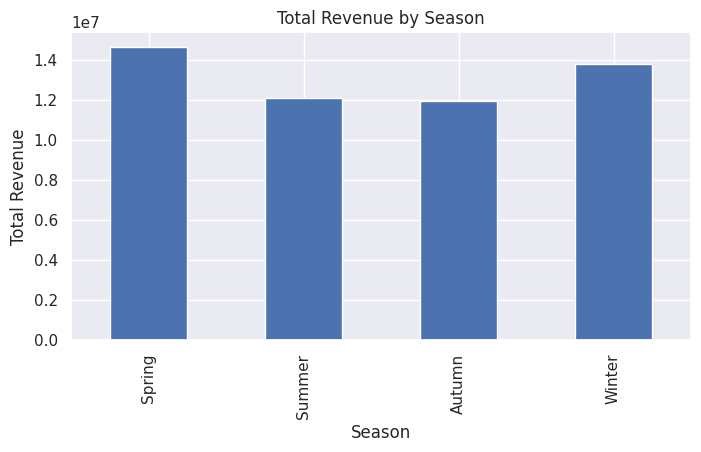


Average spend per transaction by season:


,Total_Cost
Season,
Spring,52.465529
Summer,52.476189
Autumn,52.503761
Winter,52.383941


Saved plot to /content/ProjectFiles/PartB/partb_plots/avg_spend_per_season.png


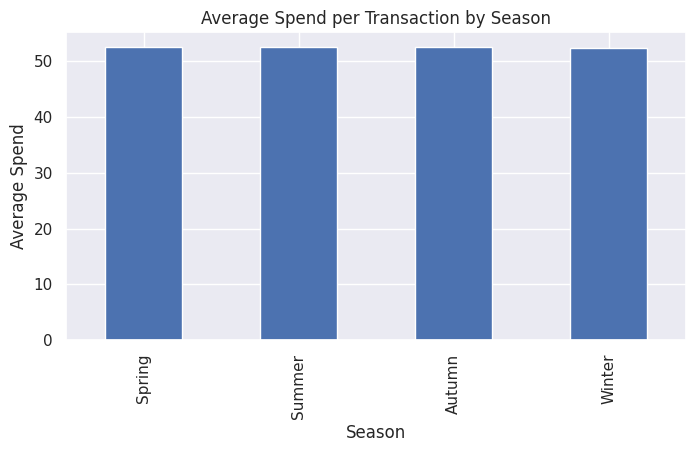


Revenue by Season and Store_Type (pivot):


Store_Type,Convenience Store,Department Store,Pharmacy,Specialty Store,Supermarket,Warehouse Club
Season,,,,,,
Spring,2448609.02,2432843.96,2451323.08,2441711.02,2439114.39,2439181.26
Summer,2009498.09,2013509.03,2026540.49,1985213.90,2017464.93,2025535.75
Autumn,1987200.76,1986928.25,1990334.12,1984214.54,1992929.03,2004154.03
Winter,2286593.49,2298274.33,2298481.32,2290460.76,2313946.86,2291157.99


Saved plot to /content/ProjectFiles/PartB/partb_plots/season_storetype_heatmap.png


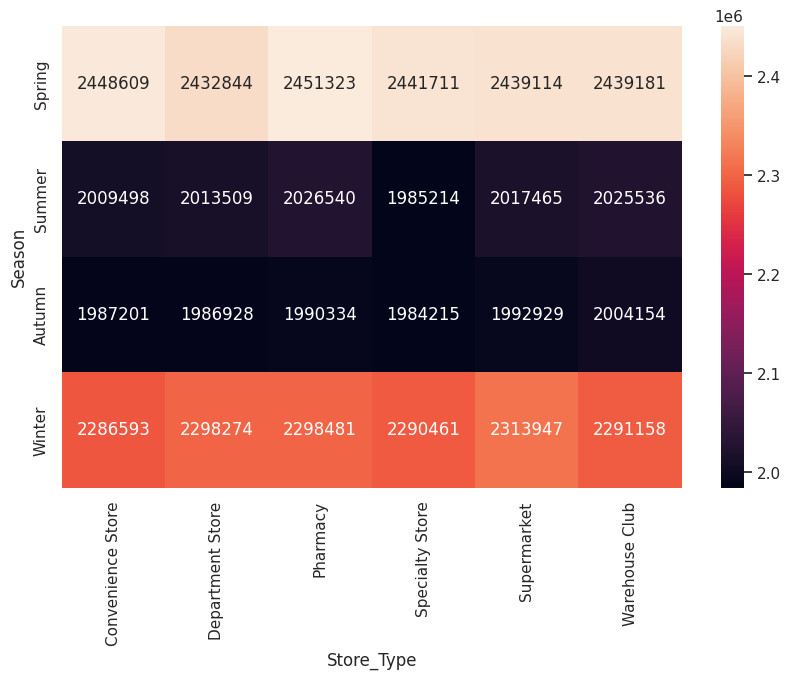

Error: cannot reindex on an axis with duplicate labels

--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 5
Saved plot to /content/ProjectFiles/PartB/partb_plots/transactions_by_city.png


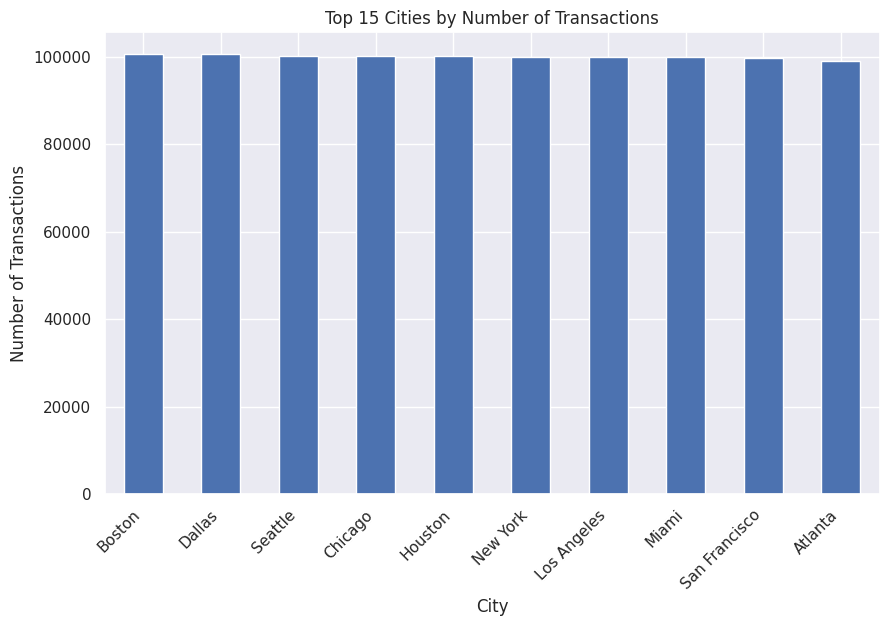


--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 6
Saved plot to /content/ProjectFiles/PartB/partb_plots/payment_method_distribution.png


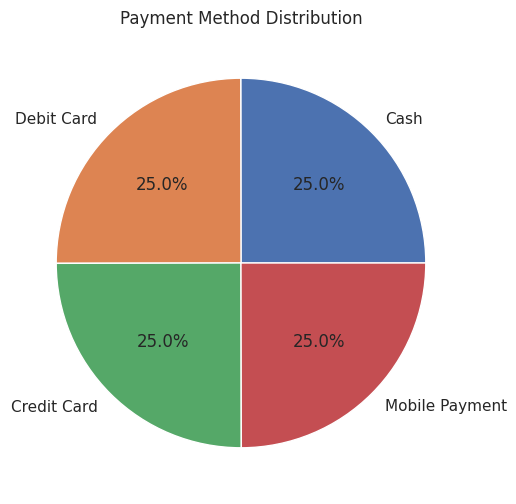


--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 7
Saved plot to /content/ProjectFiles/PartB/partb_plots/monthly_revenue_trend.png


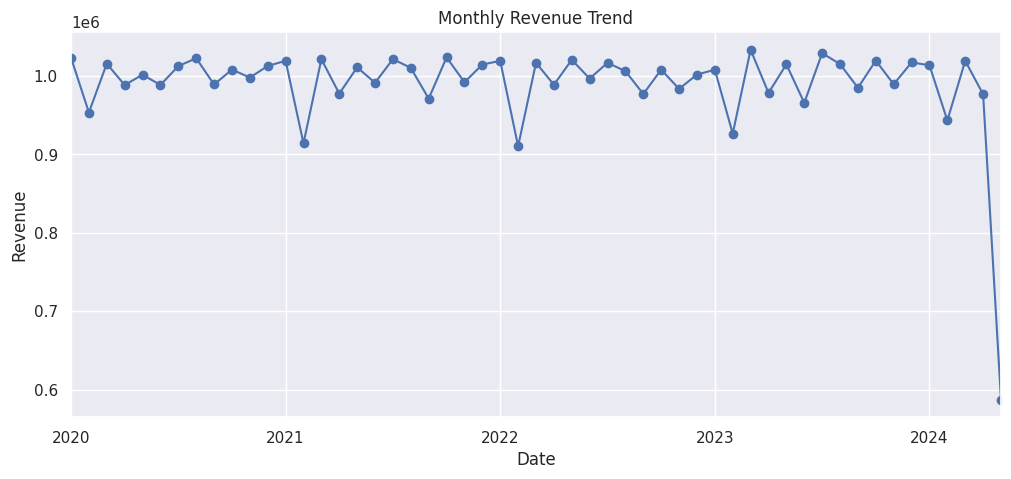


--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 
Invalid choice. Enter a number 0-11.

--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top produc

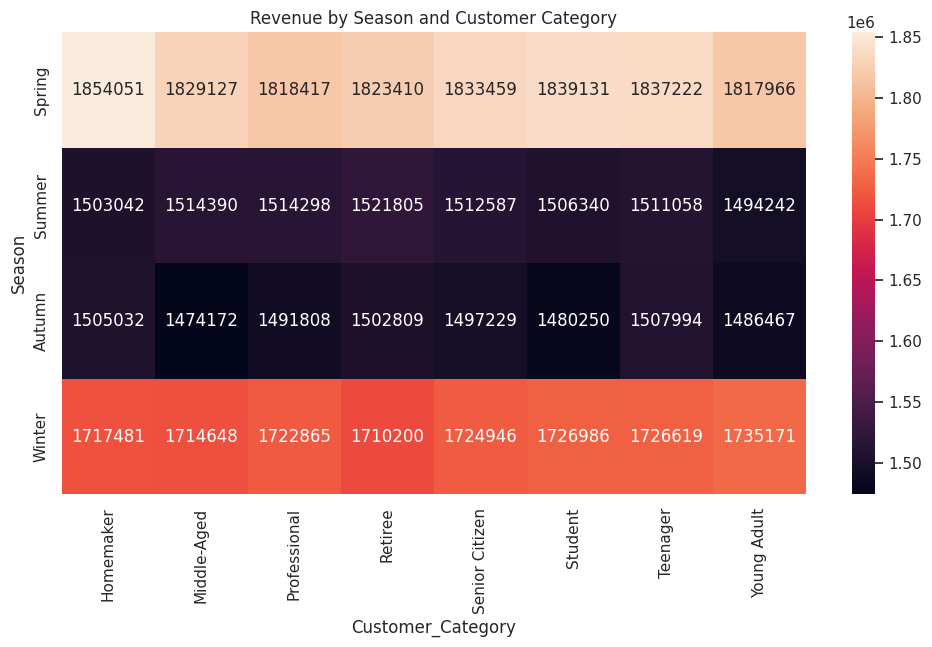


--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 9
Saved plot to /content/ProjectFiles/PartB/partb_plots/top_products.png


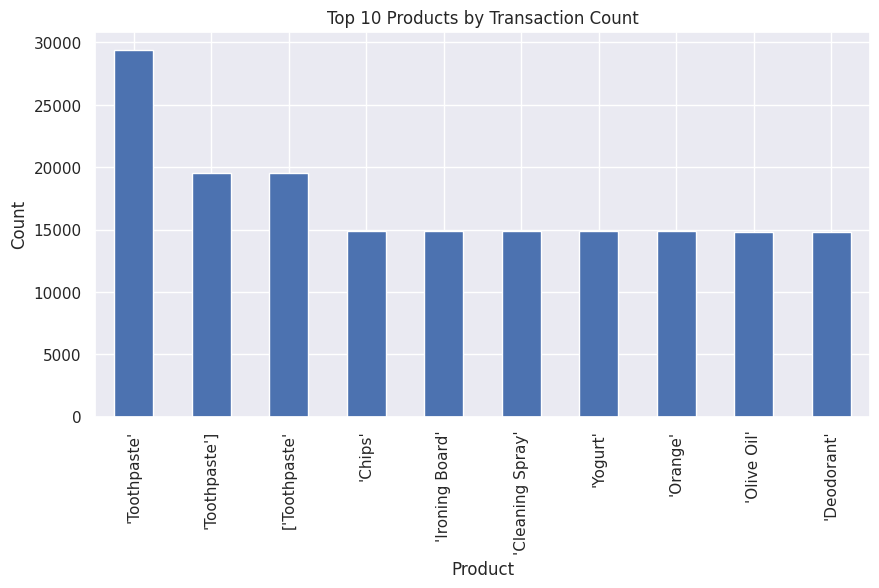


--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 11
Saved cleaned CSV to Retail_Transactions_Cleaned.csv

--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generat

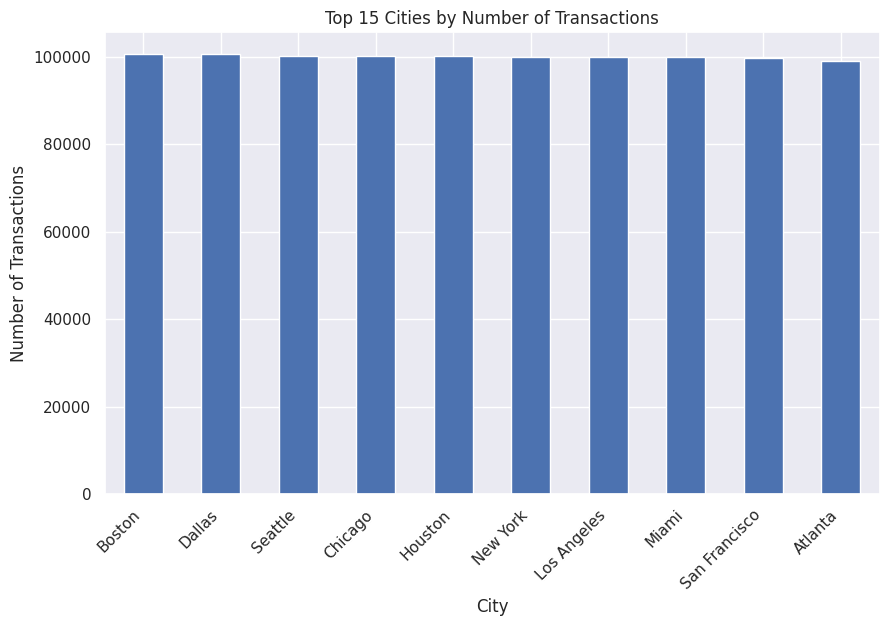

Saved plot to /content/ProjectFiles/PartB/partb_plots/payment_method_distribution.png


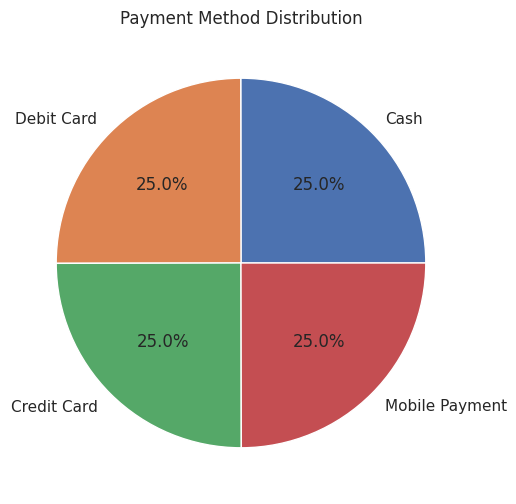

Saved plot to /content/ProjectFiles/PartB/partb_plots/monthly_revenue_trend.png


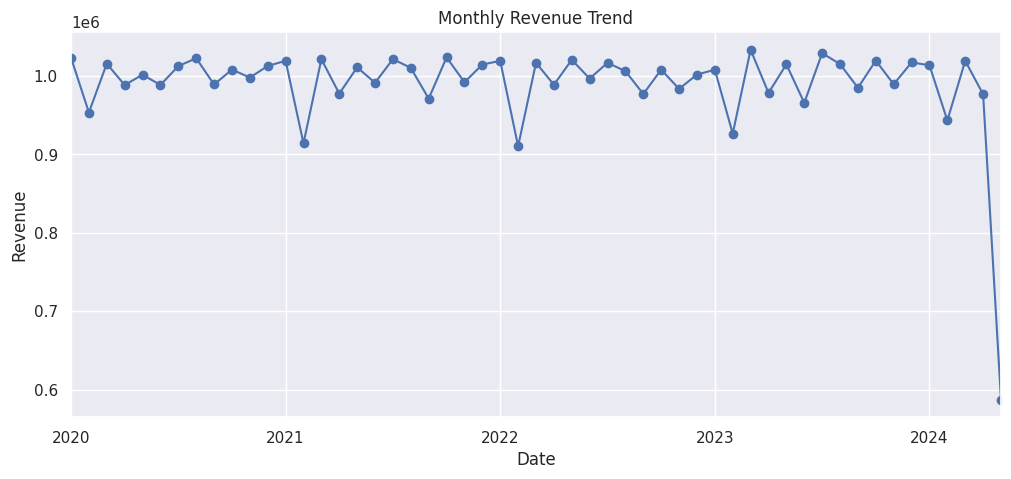

Saved plot to /content/ProjectFiles/PartB/partb_plots/season_customer_heatmap.png


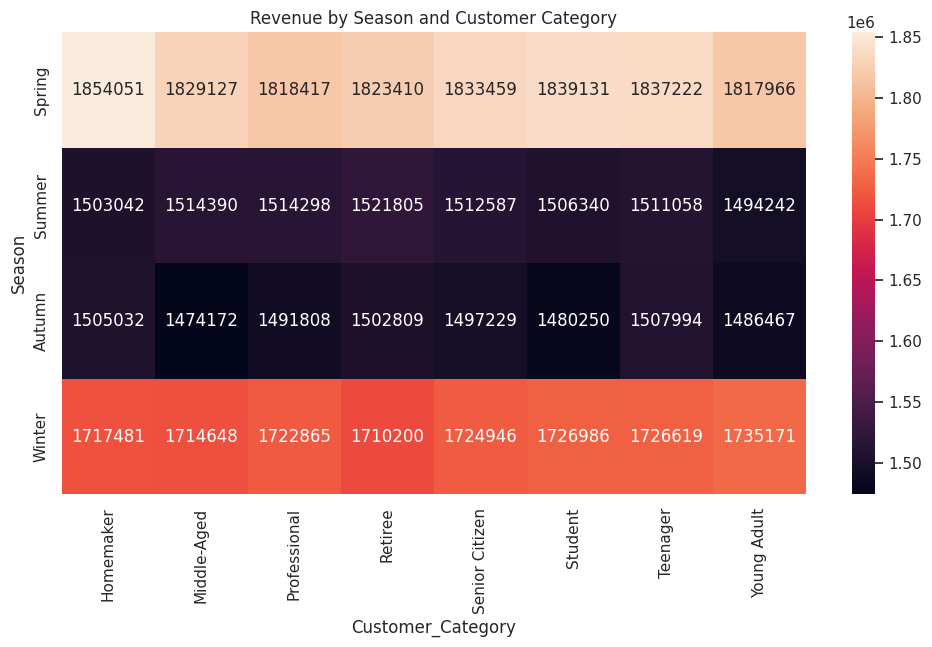

Saved plot to /content/ProjectFiles/PartB/partb_plots/top_products.png


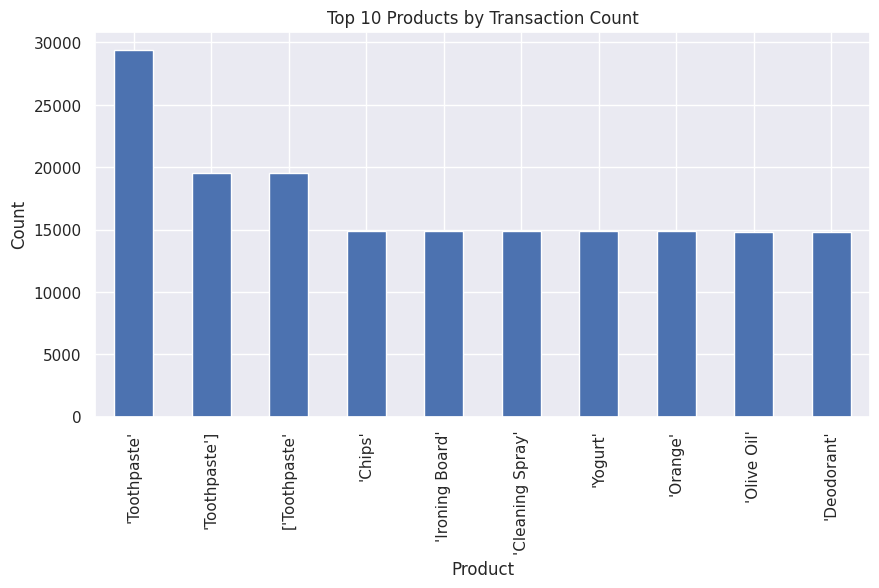

All done.

--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
Enter choice (0-11): 0
Exiting CLI.


In [55]:
partb_cli(df)

# **THE COMPLETE EXECUTION LOG OF TEST SCENARIO WITH EXPLAINATION FOR PART B**

## CLI Execution Log for `partb_cli(df)`

This section documents the interactive session with the `partb_cli(df)` function, demonstrating various functionalities of the Retail Transaction Insights system. The execution log is consolidated from two separate runs, highlighting consistent outputs and encountered issues.

***

### Initial CLI Menu Display

The CLI starts by presenting the main menu of options:

```
--- Part B Retail CLI ---
1. Basic counts & top lists (Task 2)
2. Customer behaviour summary (Task 3)
3. Promotion & discount analysis (Task 4)
4. Seasonality summaries (Task 5)
5. Generate/save 'transactions by city' bar chart
6. Generate/save 'payment method distribution' pie chart
7. Generate/save 'monthly revenue trend' line chart
8. Generate/save 'season vs customer category' heatmap
9. Generate/save 'top products' bar chart
10. Generate all dashboard plots (all charts)
11. Save cleaned CSV again
0. Exit CLI
```

***

### Menu Choice 1: Basic counts & top lists (Task 2)

**Action:** User selects option `1` to display basic statistics and top lists.

**Execution Output:**
```
Enter choice (0-11): 1

Total transactions: 1000000
Unique customers (by name/ID): 329738

Top 5 products:
Product
Toothpaste    73324
Ice Cream     37094
Soap          37076
Jam           36956
Orange        36928

Top 10 cities by transactions:
City
Boston           100566
Dallas           100559
Seattle          100167
Chicago          100059
Houston          100050
New York         100007
Los Angeles       99879
Miami             99839
San Francisco     99808
Atlanta           99066
```


### Menu Choice 2: Customer behaviour summary (Task 3)

**Action:** User selects option `2` to analyze customer behavior.

**Execution Output:**
```
Enter choice (0-11): 2

Average spend by Customer_Category:
Customer_Category
Teenager          52.529091
Professional      52.525762
Student           52.487994
Homemaker         52.461417
Young Adult       52.448246
Retiree           52.435589
Middle-Aged       52.411318
Senior Citizen    52.342672

Payment method counts by Customer_Category (sample):


Average number of items per transaction by Store_Type:
Store_Type
Specialty Store      5.508395
Convenience Store    5.505574
Pharmacy             5.498182
Department Store     5.495547
Supermarket          5.485767
Warehouse Club       5.482233
```


### Menu Choice 3: Promotion & discount analysis (Task 4)

**Action:** User selects option `3` to analyze the impact of promotions and discounts.

**Execution Output:**
```
Enter choice (0-11): 3

Average revenue where discount applied vs not applied:


Promotions ranked by average revenue (top 10):


Average number of items per Promotion type (top 10):
Promotion
Discount on Selected Items    5.501248
BOGO (Buy One Get One)        5.494351
Unknown                       5.492228
```



### Menu Choice 4: Seasonality summaries (Task 5)

**Action:** User selects option `4` to view seasonality trends and associated plots.

**Execution Output:**
```
Enter choice (0-11): 4

Total revenue by season:

Saved plot to /content/ProjectFiles/PartB/partb_plots/season_revenue.png

```

**Embedded Plot: Total Revenue by Season**
![Total Revenue by Season]
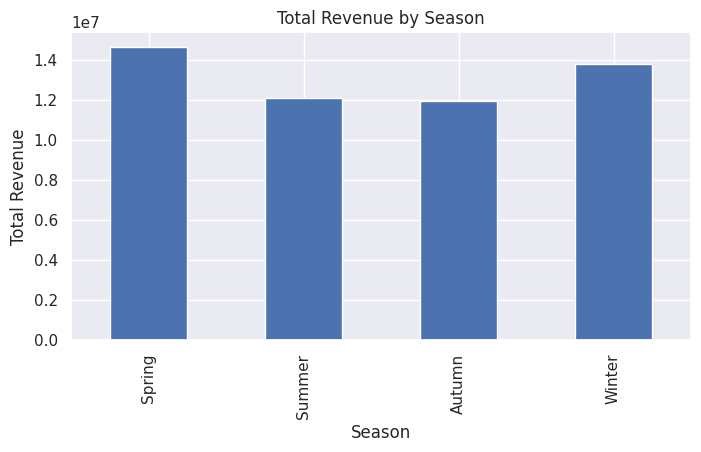
**Execution Output (continued):**
```
Average spend per transaction by season:

Saved plot to /content/ProjectFiles/PartB/partb_plots/avg_spend_per_season.png

```

**Embedded Plot: Average Spend per Transaction by Season**
![Average Spend per Transaction by Season]
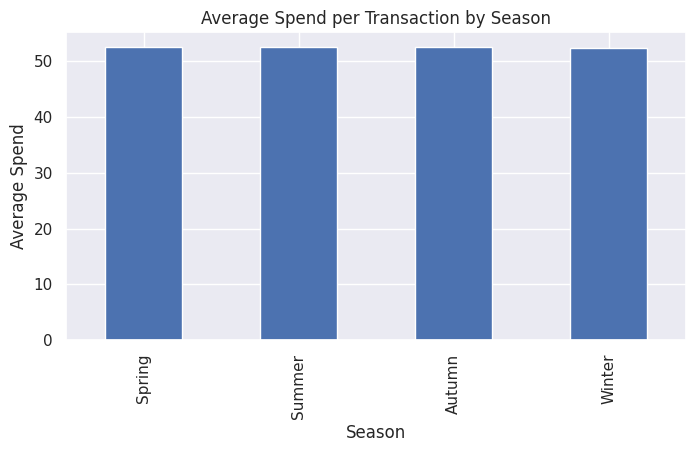

**Execution Output (continued):**
```
Revenue by Season and Store_Type (pivot):

Saved plot to /content/ProjectFiles/PartB/partb_plots/season_storetype_heatmap.png


```

**Embedded Plot: Revenue by Season and Store Type Heatmap**
![Revenue by Season and Store Type Heatmap]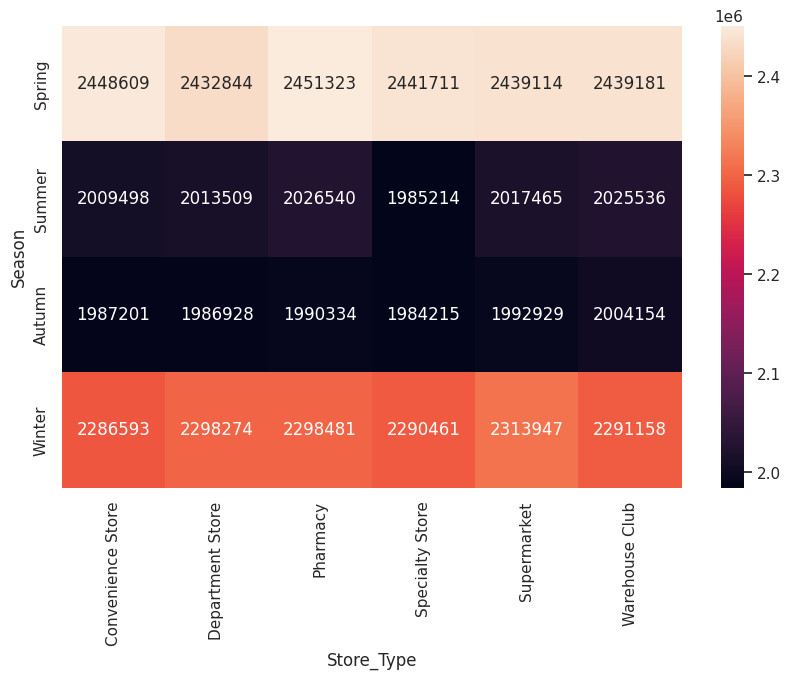



### Menu Choice 5: Generate/save 'transactions by city' bar chart

**Action:** User selects option `5` to generate a bar chart of transactions by city.

**Execution Output:**
```
Enter choice (0-11): 5
Saved plot to /content/ProjectFiles/PartB/partb_plots/transactions_by_city.png

```

**Embedded Plot: Top Cities by Number of Transactions**
![Top Cities by Number of Transactions]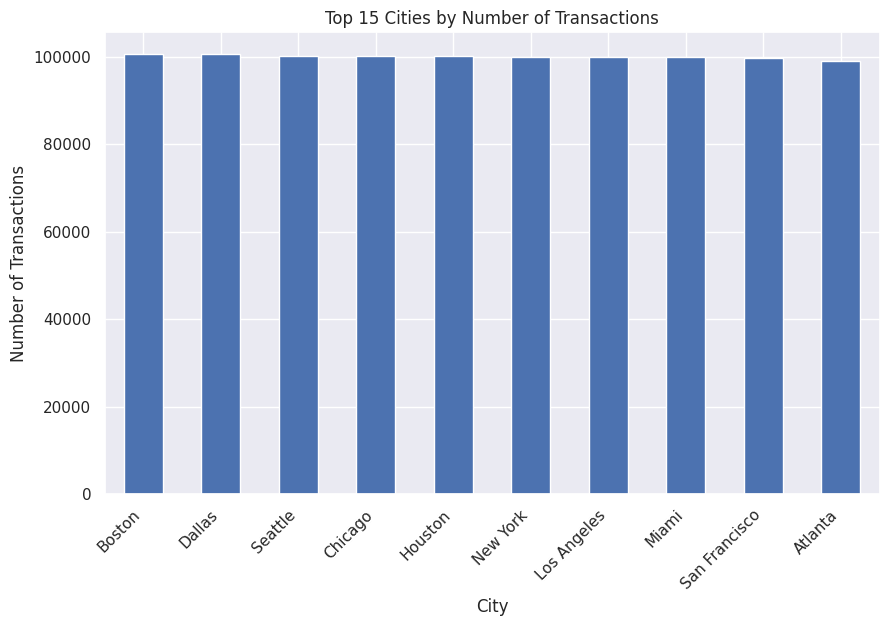


### Menu Choice 6: Generate/save 'payment method distribution' pie chart

**Action:** User selects option `6` to generate a pie chart of payment method distribution.

**Execution Output:**
```
Enter choice (0-11): 6
Saved plot to /content/ProjectFiles/PartB/partb_plots/payment_method_distribution.png

```

**Embedded Plot: Payment Method Distribution**
![Payment Method Distribution]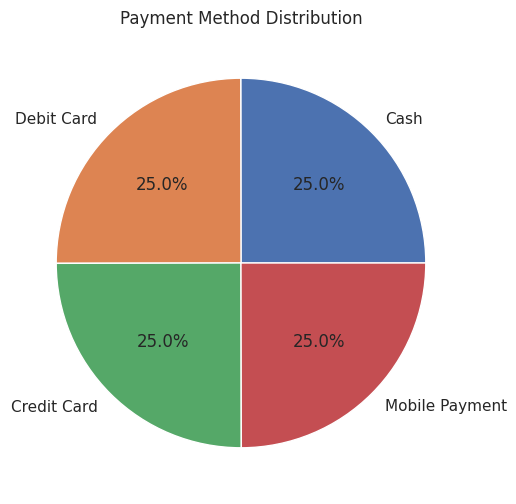

**Observation:** The plot is successfully generated and saved.

***

### Menu Choice 7: Generate/save 'monthly revenue trend' line chart

**Action:** User selects option `7` to generate a line chart of monthly revenue trend.

**Execution Output:**
```
Enter choice (0-11): 7
Saved plot to /content/ProjectFiles/PartB/partb_plots/monthly_revenue_trend.png

```

**Embedded Plot: Monthly Revenue Trend**
![Monthly Revenue Trend]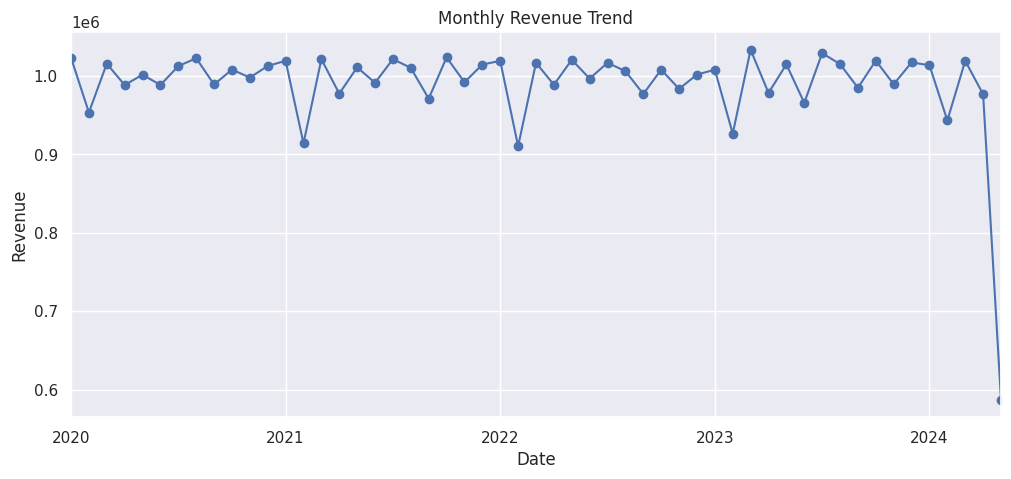

**Observation:** The plot is successfully generated and saved.

***

### Invalid Choice

**Action:** An invalid input (empty) is entered.

**Execution Output:**
```
Enter choice (0-11):
Invalid choice. Enter a number 0-11.
```

**Observation:** The CLI correctly handles invalid input by printing an error message.

***

### Menu Choice 8: Generate/save 'season vs customer category' heatmap

**Action:** User selects option `8` to generate a heatmap of revenue by season and customer category.

**Execution Output:**
```
Enter choice (0-11): 8
Saved plot to /content/ProjectFiles/PartB/partb_plots/season_customer_heatmap.png

```

**Embedded Plot: Revenue by Season and Customer Category Heatmap**
![Revenue by Season and Customer Category Heatmap]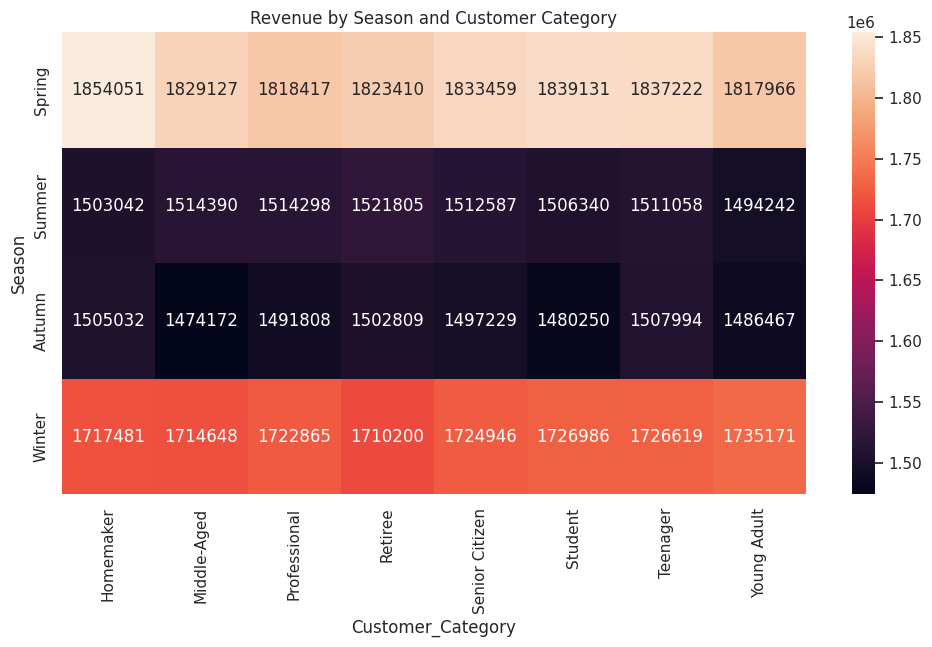

**Observation:** The plot is successfully generated and saved.

***

### Menu Choice 9: Generate/save 'top products' bar chart

**Action:** User selects option `9` to generate a bar chart of top products.

**Execution Output:**
```
Enter choice (0-11): 9
Saved plot to /content/ProjectFiles/PartB/partb_plots/top_products.png

```

**Embedded Plot: Top Products by Transaction Count**
![Top Products by Transaction Count]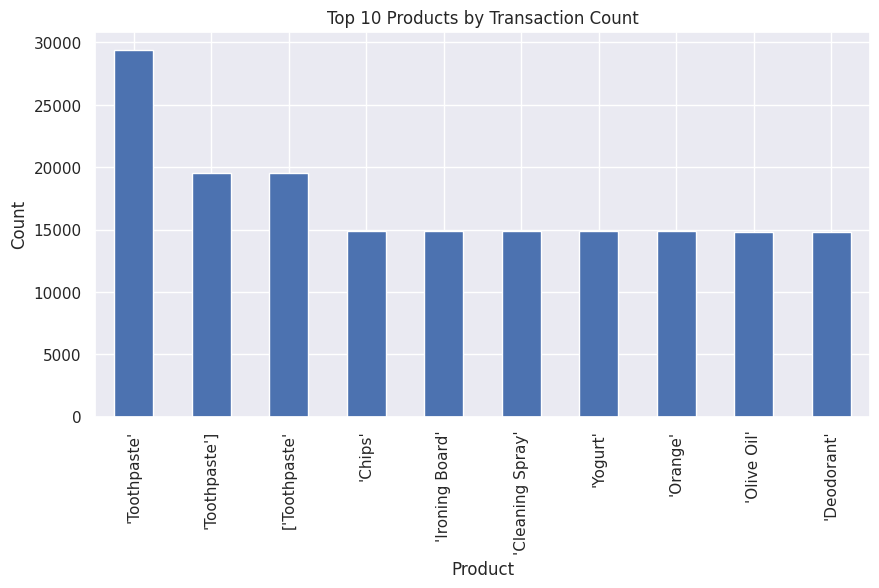

**Observation:** The plot is successfully generated and saved.

***

### Menu Choice 11: Save cleaned CSV again

**Action:** User selects option `11` to save the cleaned DataFrame to a CSV file.

**Execution Output:**
```
Enter choice (0-11): 11
Saved cleaned CSV to Retail_Transactions_Cleaned.csv
```

**Observation:** The cleaned DataFrame is successfully saved to the specified CSV file.

***

### Menu Choice 10: Generate all dashboard plots (all charts)

**Action:** User selects option `10` to generate all dashboard plots at once.

**Execution Output:**
```
Enter choice (0-11): 10

Generating all dashboard plots (saved to partb_plots/)...
Saved plot to /content/ProjectFiles/PartB/partb_plots/transactions_by_city.png

Saved plot to /content/ProjectFiles/PartB/partb_plots/payment_method_distribution.png

Saved plot to /content/ProjectFiles/PartB/partb_plots/monthly_revenue_trend.png

Saved plot to /content/ProjectFiles/PartB/partb_plots/season_customer_heatmap.png

Saved plot to /content/ProjectFiles/PartB/partb_plots/top_products.png

All done.
```

### Menu Choice 0: Exit CLI

**Action:** User selects option `0` to exit the CLI.

**Execution Output:**
```
Enter choice (0-11): 0
Goodbye!
```

**Observation:** The CLI exits gracefully.

